## HW4 音频分类

* 给定音频区分出说话人
* 主要目的：学会使用transformer
* Baselines:
    - Easy: 知道怎么使用transformer
    - Medium: 知道transformer如何调惨
    - Strong: 改变transformer的结构，使用一种transformer变体————conformer
    - Boss: 使用Self-Attention Pooling & Additive Margin Softmax进一步提升模型的表现


In [32]:
!pip install rich

In [33]:
import pandas as pd 
import numpy as np
import random
from pathlib import Path

import torch
import torch.nn as nn 
from torch.utils.data import Dataset, random_split, DataLoader
from torch import functional  as F
from torch.optim import Optimizer
from torch.optim.lr_scheduler import LambdaLR
from torch.nn.utils.rnn import pad_sequence
import math

import os
import sys
import json
from tqdm import tqdm
# 绘制评估曲线
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
from torchviz import make_dot

import warnings 
from rich.console import Console
warnings.filterwarnings('ignore')
cs = Console()

In [34]:
def model_plot(model_class, input_sample):
    clf = model_class()
    y = clf(input_sample) 
    clf_view = make_dot(y, params=dict(list(clf.named_parameters()) + [('x', input_sample)]))
    return clf_view


def all_seed(seed=6666):
    np.random.seed(seed)
    random.seed(seed)
    # CPU
    torch.manual_seed(seed)
    # GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.cuda.manual_seed(seed)
    # python全局
    os.environ['PYTHONHASHSEED'] = str(seed)
    # cudnn
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False
    print(f'Set env random_seed = {seed}')

In [35]:
all_seed(87)

Set env random_seed = 87


## 数据集

In [36]:
# 查看数据
from curses import meta


data_dir = "./Dataset"

# mapping.json
map = Path(data_dir) / "mapping.json"
print(map)
map_js = json.load(map.open())
cs.print("mapping.json | keys = ", map_js.keys())
# metadata.json
metadata = Path(data_dir) / "metadata.json"
metadata_js = json.load(metadata.open())
cs.print("metadata.json | keys = ", metadata_js.keys())
cs.print("metadata_js['n_mels'] = ", metadata_js['n_mels'])
cs.print(
    "metadata_js['speakers']['id10473'][:5] = ",
    metadata_js['speakers']['id10473'][:5],
)

# mel = torch.load(os.path.join(data_dir, "uttr-2918xxx.pt"))
# cs.print(f"(mel_len, n_mels) = {mel.shape}")
# mel

Dataset/mapping.json


mapping.json | keys =  dict_keys(['speaker2id', 'id2speaker'])

metadata.json | keys =  dict_keys(['n_mels', 'speakers'])

metadata_js['n_mels'] =  40

metadata_js['speakers']['id10473'][:5] = 
[
    {'feature_path': 'uttr-5c88b2f1803449789c36f14fb4d3c1eb.pt', 'mel_len': 652},
    {'feature_path': 'uttr-022a67baccc54bfda3567a7ac282a7b8.pt', 'mel_len': 564},
    {'feature_path': 'uttr-6a5c6e7231d642568633db13b6e429e1.pt', 'mel_len': 952},
    {'feature_path': 'uttr-e316c0cfdc8843c3ba3cfbb86af687b8.pt', 'mel_len': 1214},
    {'feature_path': 'uttr-3060b2b96bfc4614bb518914e557fea6.pt', 'mel_len': 353}
]

In [37]:
from sys import meta_path


class myDataset(Dataset):
    def __init__(self, data_dir, segment_len=128):
        super(myDataset, self).__init__()
        self.data_dir = data_dir
        self.segment_len = segment_len
        # 加载演讲者和id编码的映射
        mapping_path = Path(data_dir) / 'mapping.json'
        mapping = json.load(mapping_path.open())
        self.speaker2id = mapping['speaker2id']

        # 加载训练数据的源数据（特征文件，演讲者）
        meta_path = Path(data_dir) / 'metadata.json'
        metadata = json.load(meta_path.open())["speakers"]
        
        # 获取总演讲者数
        self.speaker_num = len(metadata.keys())
        self.data = []
        for speaker, utt in metadata.items():
            for utterance in utt:
                self.data.append([utterance["feature_path"], self.speaker2id[speaker]])
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        feat_path, speaker_id = self.data[index]
        # 载入经过预处理的mel图谱特征（mel-speatrogram）
        mel = torch.load(os.path.join(self.data_dir, feat_path))
        # 分割 mel-speatrogram
        if len(mel) > self.segment_len:
            # 开始的位置是随机的
            start = random.randint(0, len(mel) - self.segment_len)
            # 切分语音
            mel = torch.FloatTensor(mel[start: start + self.segment_len])
        else:
            mel = torch.FloatTensor(mel)
        # 将 speaker_id 转为 long 格式便于后续计算 loss
        speaker_id = torch.tensor(speaker_id, dtype=torch.long)
        return mel, speaker_id

class InferenceDataset(Dataset):
    """ 推理数据集（test） """
    def __init__(self, data_dir):
        super(InferenceDataset, self).__init__()
        test_path = Path(data_dir) / "testdata.json"
        metadata = json.load(test_path.open())
        self.data_dir = data_dir
        self.data = metadata["utterances"]

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        utterance = self.data[index]
        feat_path = utterance["feature_path"]
        mel = torch.load(os.path.join(self.data_dir, feat_path))
        return feat_path, mel
    
def inference_collate_batch(batch):
    """Collate a batch of data."""
    feat_paths, mels = zip(*batch)
    return feat_paths, torch.stack(mels)



## Transformer 模型

In [38]:
class Classifier(nn.Module):
    def __init__(self, input_dim=40, d_model=80, n_spks=600, dropout=0.1):
        super(Classifier, self).__init__()
        self.pre_net = nn.Linear(input_dim, d_model)
        # TODO:
        # 修改Transformer，为Conformer
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, # self_attn [Q, K, V] shape=(d_model * 3, d_model)
            dim_feedforward=256,
            nhead=2,
            batch_first=True,
            activation="gelu"    
        )
        self.pred_layer = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_spks)
        )

    def forward(self, mels):
        out = self.pre_net(mels) # (batch_size, seq_length, d_model)
        out = self.encoder_layer(out) # (batch_size, seq_length, d_model)

        # mean pooling，平均池化将可变长度的时序特征转换为固定长度的表示，适用于分类任务。
        stats = out.mean(dim=1) # (batch_size, d_model)

        out = self.pred_layer(stats) # (batch_size, n_spks)
        return out
        

## 学习率设置

* 与训练CNN不同，训练前期逐步增加学习率（Warm up）有利于模型训练transformer.
* 按照 `plot_lr` 设计一个 Warm up 的学习率变化框架
    - 设置学习率在 0 到优化器设置的学习率的区间
    - 在初期（Warmup period）学习率从零增长到初始学习率

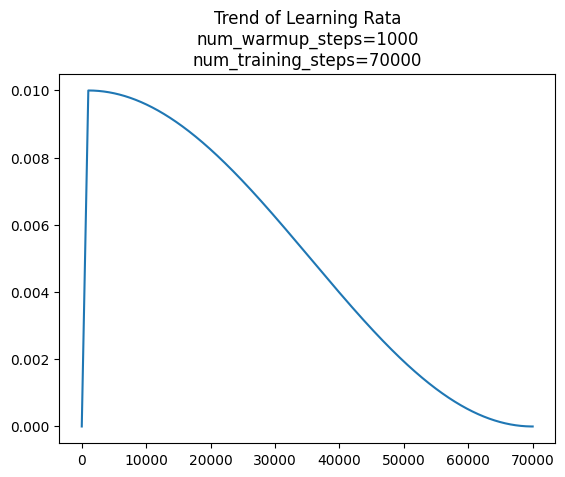

In [39]:
def plot_lr():
    num_warmup_steps = 1000
    num_training_steps = 70000
    lr = 0.01
    res_list = []
    for current_step in range(70000):
        if current_step < num_warmup_steps:
            res = float(current_step) / float(max(1, num_warmup_steps))
            res_list.append(res * lr)
            continue
        progress = float(current_step - num_warmup_steps) / float(
                        max(1, num_training_steps - num_warmup_steps)
                    )
        # 余弦退火：cos(π * progress) 即 cos0=1 👉 cosπ=-1 递减
        res = 0.5 * (1.0 + math.cos(math.pi * float(0.5) * 2.0 * progress))
        res_list.append(res * lr)

    plt.plot(res_list)
    plt.title(f"Trend of Learning Rata\nnum_warmup_steps={num_warmup_steps}\nnum_training_steps={num_training_steps}")
    plt.show()

plot_lr()

In [40]:
def get_cosine_schedule_with_warmup(
    opt: Optimizer,
    num_warmup_steps: int,
    num_training_steps: int,
    num_cycles: float = 0.5,
    last_epoch: int = -1
):
    """
    创建一个学习率变化策略,
    学习率跟随cosine值变化,
    在warm up时间段内变化区间在:
        0 -> 优化器设置的学习率 .
    Args:
        opt (Optimizer): 优化器类
        num_warmup_steps (int): 多少步增加一下lr
        num_training_steps (int): 总训练步骤
        num_cycles (float, optional): 变化周期. 默认为 0.5.
        last_epoch (int, optional): _description_. Defaults to -1.
    """
    def lr_lambda(current_step):
        # warmup
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        # 衰减
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        return max(
            0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress))
        )
    return LambdaLR(opt, lr_lambda, last_epoch)

## 训练部分

与前面作业的 trainer 基本一致，主要区别是使用上述的 lr scheduler。

In [41]:
def trainer(train_loader, valid_loader, model, config, device, rest_net_flag=False):
    # 对于分类任务, 我们常用cross-entropy评估模型表现.
    criterion = nn.CrossEntropyLoss()
    # 初始化优化器
    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate']) 
    if config['scheduler_flag']:
        scheduler = get_cosine_schedule_with_warmup(optimizer, config['warmup_steps'], len(train_loader) * config['n_epochs'])
    # 模型存储位置
    save_path =  config['save_path']

    writer = SummaryWriter()
    if not os.path.isdir('./models'):
        os.mkdir('./models')

    n_epochs, best_loss, step, early_stop_count = config['n_epochs'], math.inf, 0, 0
    for epoch in range(n_epochs):
        model.train()
        loss_record = []
        train_accs = []
        train_pbar = tqdm(train_loader, position=0, leave=True)

        for x, y in train_pbar:
            optimizer.zero_grad()             
            x, y = x.to(device), y.to(device)  
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            if config['scheduler_flag']:
                scheduler.step() # 更新学习率
            step += 1
            acc = (pred.argmax(dim=-1) == y.to(device)).float().mean()
            l_ = loss.detach().item()
            loss_record.append(l_)
            train_accs.append(acc.detach().item())
            train_pbar.set_description(f'Epoch [{epoch+1}/{n_epochs}]')
            train_pbar.set_postfix({'loss': f'{l_:.5f}', 'acc': f'{acc:.5f}'})
        
        
        mean_train_acc = sum(train_accs) / len(train_accs)
        mean_train_loss = sum(loss_record)/len(loss_record)
        writer.add_scalar('Loss/train', mean_train_loss, step)
        writer.add_scalar('ACC/train', mean_train_acc, step)
        
        model.eval() # 设置模型为评估模式
        loss_record = []
        test_accs = []
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                pred = model(x)
                loss = criterion(pred, y)
                acc = (pred.argmax(dim=-1) == y.to(device)).float().mean()

            loss_record.append(loss.item())
            test_accs.append(acc.detach().item())
            
        mean_valid_acc = sum(test_accs) / len(test_accs)
        mean_valid_loss = sum(loss_record)/len(loss_record)
        print(f'Epoch [{epoch+1}/{n_epochs}]: Train loss: {mean_train_loss:.4f},acc: {mean_train_acc:.4f} Valid loss: {mean_valid_loss:.4f},acc: {mean_valid_acc:.4f} ')
        writer.add_scalar('Loss/valid', mean_valid_loss, step)
        writer.add_scalar('ACC/valid', mean_valid_acc, step)
        if mean_valid_loss < best_loss:
            best_loss = mean_valid_loss
            torch.save(model.state_dict(), save_path) # 保存最优模型
            print('Saving model with loss {:.3f}...'.format(best_loss))
            early_stop_count = 0
        else: 
            early_stop_count += 1

        if early_stop_count >= config['early_stop']:
            print('\nModel is not improving, so we halt the training session.')
            return

## 参数设置

In [42]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
config = {
    'seed': 87,
    'dataset_dir': "./Dataset",
    'n_epochs': 35,      
    'batch_size': 64, 
    
    'scheduler_flag': True,
    'valid_steps': 2000,
    'warmup_steps': 1000,
    # 'total_steps': 70000, # len(train) * n_epochs
    'learning_rate': 1e-3,          
    'early_stop': 300,
    'n_workers': 8,
    'save_path': './models/model.ckpt'
}
print(device)
all_seed(config['seed'])

cpu
Set env random_seed = 87


## 导入数据集

- 将数据集分割成训练集(90%)和验证集(10%).
- 创建dataloader用于模型训练.
- 用`pad_sequence`方法将一个batch中的数据都扩展成一样的长度(`collate_batch`)  

    Example:
```python
from torch.nn.utils.rnn import pad_sequence
a = torch.ones(25, 40)
b = torch.ones(22, 40)
c = torch.ones(15, 40)
pad_sequence([a, b, c], batch_first=True).size() # 都扩展成一样长
torch.Size([3, 25, 40])
```

In [45]:
def collate_batch(batch):
    # 将一个batch中的数据合并
    """ Collate a batch of data. """
    mel, speaker = zip(*batch)
    # 通过pad保持一个batch中的长度全部一致，并设置batch的维度在最前的一维
    mel = pad_sequence(mel, batch_first=True, padding_value=-20) # 填补的值为-20，做log运算后是一个很小的值，符合要求
    # mel: (batch_size, seq_len, n_mels=40)
    return mel, torch.tensor(speaker, dtype=torch.long)

data_dir = config["dataset_dir"]
dataset = myDataset(data_dir)
speaker_num = dataset.speaker_num
speaker2id = dataset.speaker2id
# 将数据集拆分为训练集和验证集
train_len = int(len(dataset) * 0.9)
valid_len = len(dataset) - train_len
train_dataset, valid_dataset = random_split(dataset, [train_len, valid_len])
test_dataset = InferenceDataset(data_dir)

train_loader = DataLoader(
    train_dataset, 
    batch_size=config["batch_size"], 
    shuffle=True,
    drop_last=True,
    num_workers=config["n_workers"],
    pin_memory=True,
    collate_fn=collate_batch,
)

valid_loader = DataLoader(
    valid_dataset, 
    batch_size=config["batch_size"],
    num_workers=config["n_workers"],
    drop_last=True,
    pin_memory=True,
    collate_fn=collate_batch,
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=config["batch_size"],
    num_workers=config["n_workers"],
    shuffle=False,
    drop_last=False,
    pin_memory=True,
    collate_fn=inference_collate_batch,
)

## 开始训练

我的 mac 和 windows 的硬件资源不够，改用hpc运行。


In [47]:
model = Classifier(
    input_dim=40, # n_mel
    d_model=80,
    n_spks=600,
    dropout=0.1,
).to(device)

# trainer(train_loader, valid_dataset, model, config, device)

## 测试并生成预测结果的csv

In [ ]:
import test


model_best = Classifier().to(device)
model_best.load_state_dict(torch.load(config["save_path"]))
model_best.eval()
mapping_path = Path(data_dir) / "mapping.json"
mapping = json.load(mapping_path.open())
pred_id = []
pred_final_cls = []
with torch.no_grad():
    for name, data in tqdm(test_loader):
        test_pred = model_best(data.to(device))
        test_label = np.argmax(test_pred.cpu().data.numpy(), axis=1)
        pred_id += name
        pred_final_cls += [mapping["id2speaker"][str(test_label[0])]]

In [ ]:
df = pd.DataFrame()
df["Id"] = pred_id
df["Category"] = pred_final_cls
df.to_csv("submission.csv", index=False)